In [1]:
import cafe

img_dir = "img/26.01.28-metric_feature"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

数据导入与预处理

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

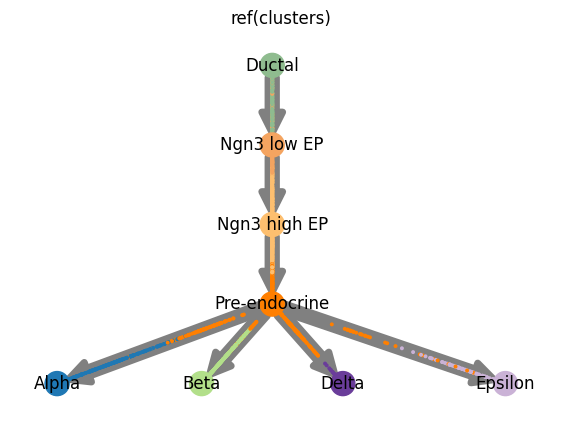

In [2]:
fadata = cafe.data.read_pancreas()
cafe.plot.plot_graph(fadata)
fadata

提取轨迹

WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           


AnnData object with n_obs × n_vars = 581 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

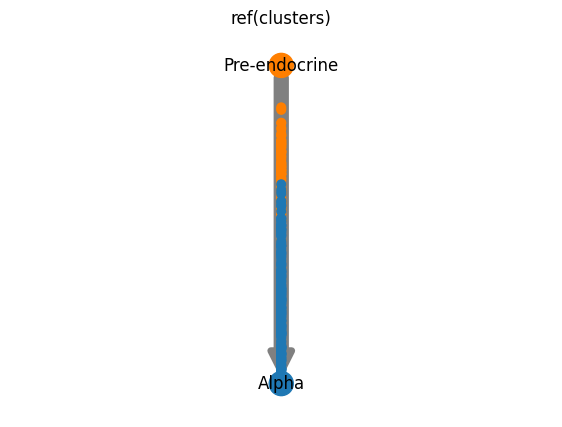

In [6]:
edge_list = [
    # ("Ngn3 high EP","Pre-endocrine"),
    ("Pre-endocrine","Alpha"),
]
fadata_subset = fadata.subset_trajectory(edge_list=edge_list)
cafe.plot.plot_graph(fadata_subset)
fadata_subset

In [8]:
import scvelo as scv

scv.pp.filter_and_normalize(fadata_subset, min_counts=3, min_counts_u=3, n_top_genes=2000)
fadata_subset

Filtered out 8 genes that are detected 3 counts (spliced).
Filtered out 76 genes that are detected 3 counts (unspliced).
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.


AnnData object with n_obs × n_vars = 581 × 1916
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename', 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [9]:
from cafe.metric.metric_featureimp import calculate_overall_feature_importance

featureimp_df = calculate_overall_feature_importance(fadata_subset)
featureimp_df["gene"] = fadata_subset.var_names[featureimp_df["feature_id"]]
featureimp_df

,feature_id,importance,gene
0,1490,0.045501,Iapp
1,910,0.038186,Gcg
2,20,0.037706,Fev
3,1911,0.030133,Tmem27
4,1855,0.029005,Tmsb15l
...,...,...,...
1911,763,0.000000,BC051142
1912,762,0.000000,Tap2
1913,761,0.000000,Zfp952
1914,760,0.000000,Pknox1


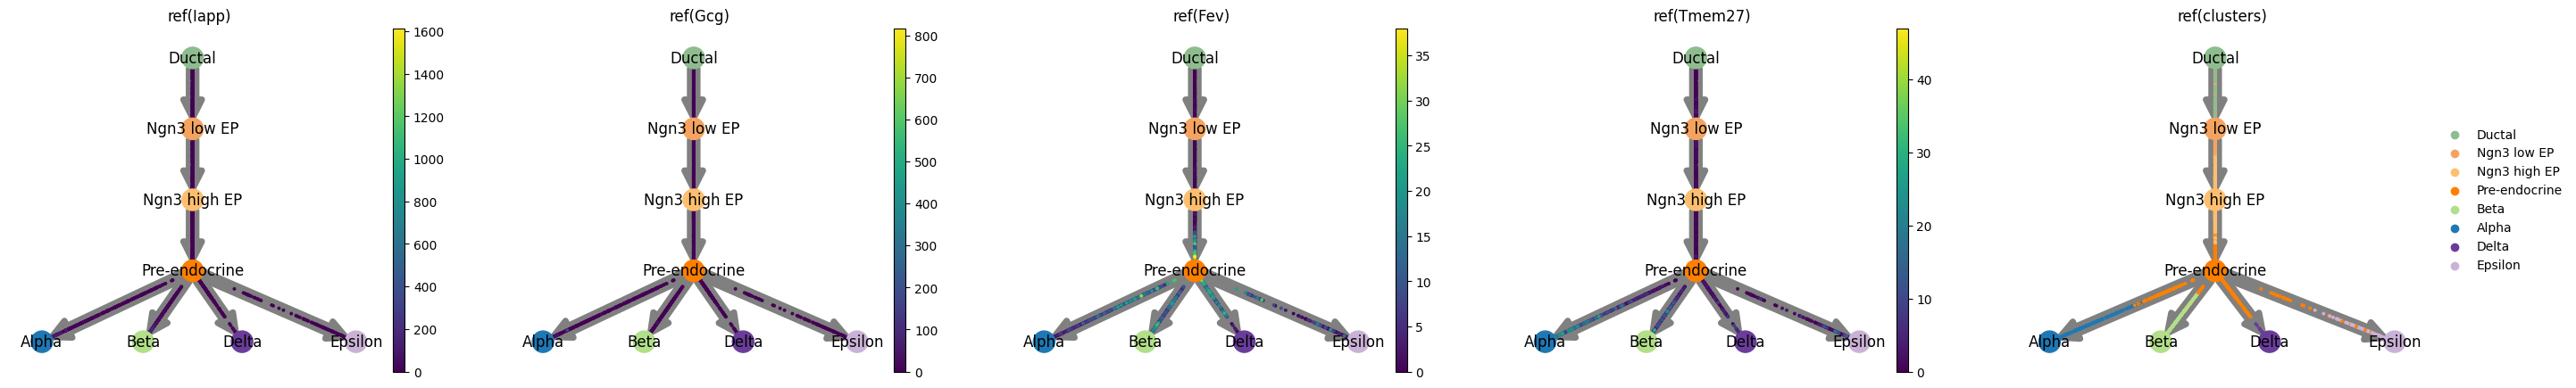

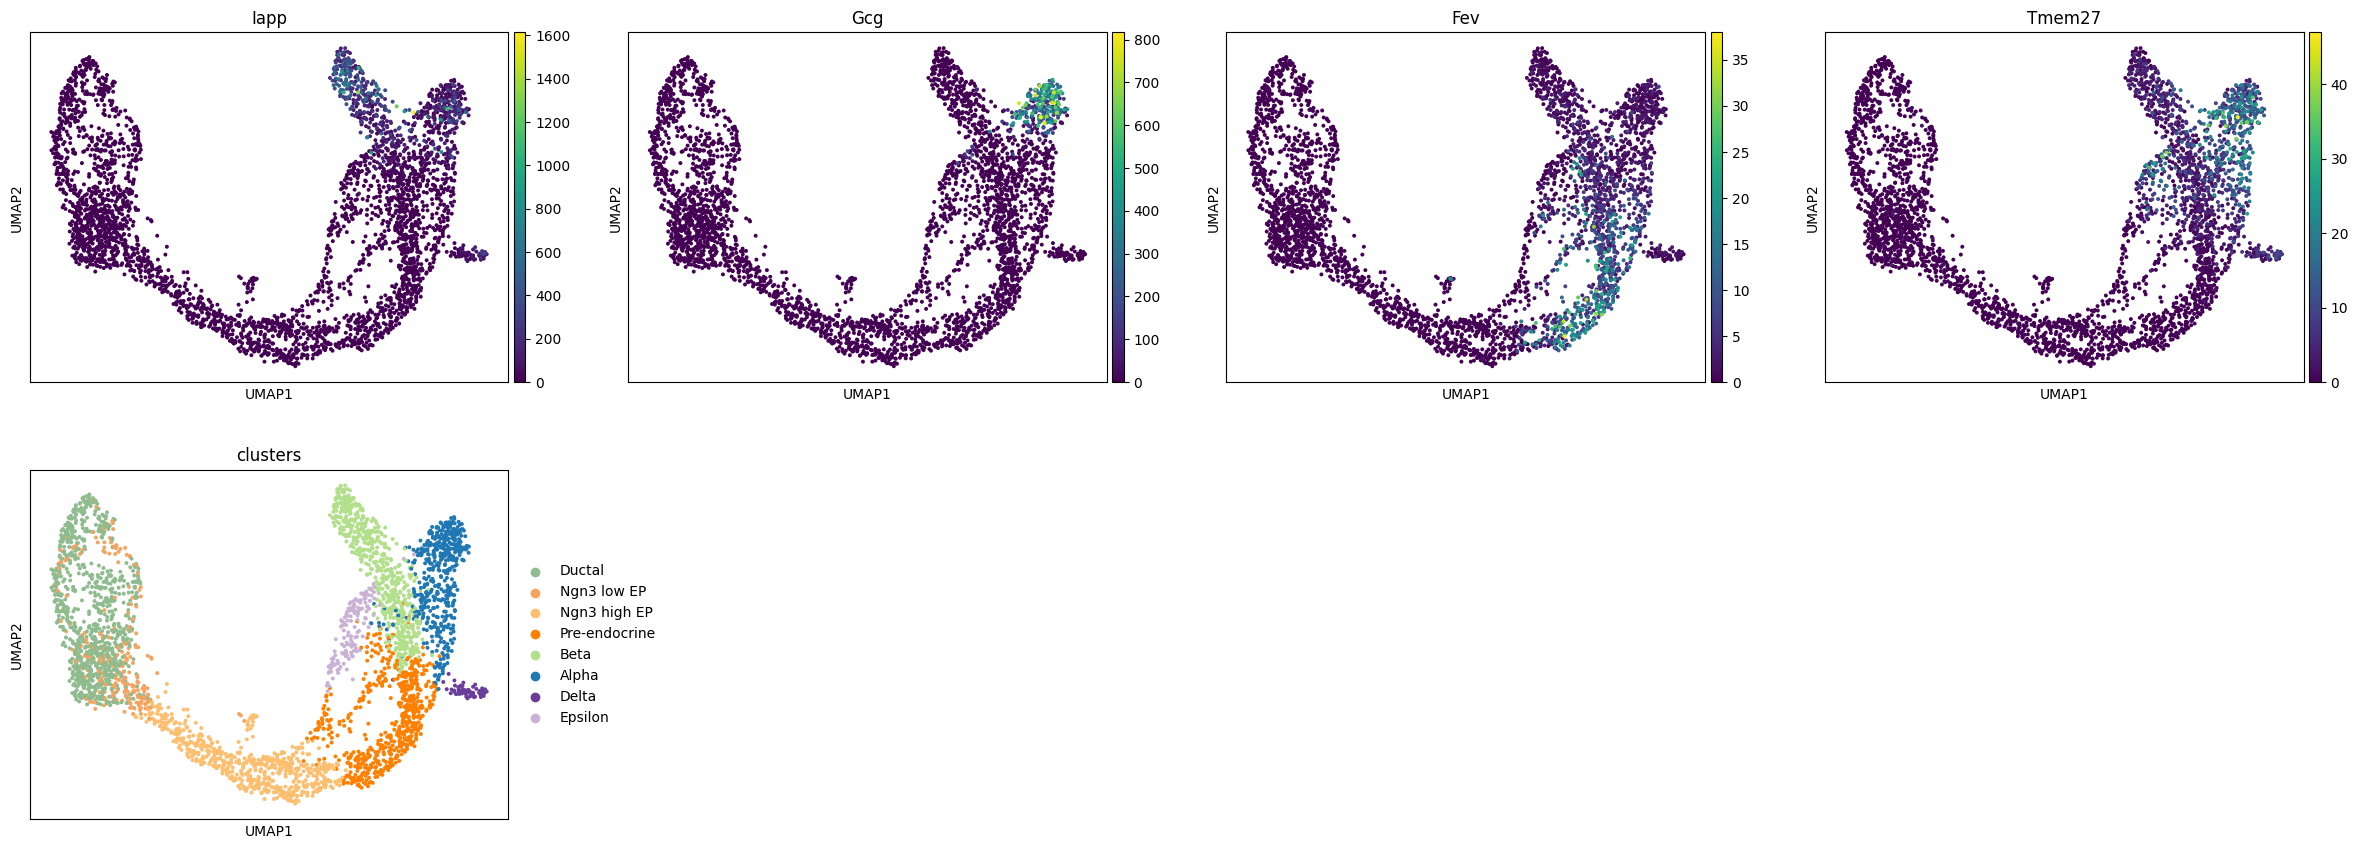

In [18]:
import scanpy as sc
top_n = 3
gene_list = featureimp_df.loc[:top_n, "gene"].tolist()

cafe.plot.plot_graph(fadata, color=gene_list+["clusters"])
sc.pl.umap(fadata, color=gene_list+["clusters"])